# Modelo de Stacking — Detección de Fraude en Tarjetas de Crédito

**Objetivo:** Entrenar y validar un modelo de Stacking para la detección de transacciones fraudulentas.  
**Entrada:** `df_train.csv` y `df_test.csv` generados en el notebook de EDA (ya preprocesados).  

**Estructura:**
1. Librerías y carga de datos
2. Tratamiento del desbalanceo (SMOTE)
3. Definición del modelo de Stacking (6 modelos base + metamodelo)
4. Entrenamiento
5. Evaluación del Stacking
6. Comparativa: modelos base individuales vs Stacking
7. Visualizaciones: Curva ROC, PR, Matriz de Confusión, Importancia de variables

## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings


# Modelos base
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier

# Desbalanceo
from imblearn.over_sampling import SMOTE

# Métricas
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    f1_score, accuracy_score, matthews_corrcoef, average_precision_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga de datos

Cargamos directamente los datasets ya preprocesados por el notebook de EDA.  
**No se aplica ninguna transformación adicional** — el escalado y el encoding ya fueron realizados y el preprocesador se ajustó exclusivamente sobre el conjunto de entrenamiento.

In [2]:
df_train = pd.read_csv('../data/df_train.csv')
df_test  = pd.read_csv('../data/df_test.csv')

feature_cols = [c for c in df_train.columns if c != 'is_fraud']

X_train = df_train[feature_cols]
y_train = df_train['is_fraud']
X_test  = df_test[feature_cols]
y_test  = df_test['is_fraud']

print(f'Train: {X_train.shape[0]:,} muestras × {X_train.shape[1]} features')
print(f'Test:  {X_test.shape[0]:,} muestras × {X_test.shape[1]} features')
print(f'\nDistribución del target en train:')
vc = y_train.value_counts()
print(f'  Legítimas: {vc[0]:>7,}  ({vc[0]/len(y_train)*100:.2f}%)')
print(f'  Fraudes:   {vc[1]:>7,}  ({vc[1]/len(y_train)*100:.2f}%)')

Train: 271,685 muestras × 45 features
Test:  67,922 muestras × 45 features

Distribución del target en train:
  Legítimas: 270,259  (99.48%)
  Fraudes:     1,426  (0.52%)


## 3. Tratamiento del desbalanceo — SMOTE

El dataset presenta un ratio de fraude de ~0.52%, lo que provoca que los modelos ignoren la clase minoritaria.  
Aplicamos **SMOTE** (*Synthetic Minority Over-sampling Technique*) únicamente sobre el conjunto de **entrenamiento**, generando muestras sintéticas de la clase fraude hasta alcanzar una proporción 1:3 (fraude:legítima).

> **Importante:** SMOTE se aplica **después** del split train/test y **solo en train**, para evitar data leakage.

Distribución tras SMOTE:
  Legítimas: 270,259  (76.92%)
  Fraudes:    81,077  (23.08%)
  Total:     351,336


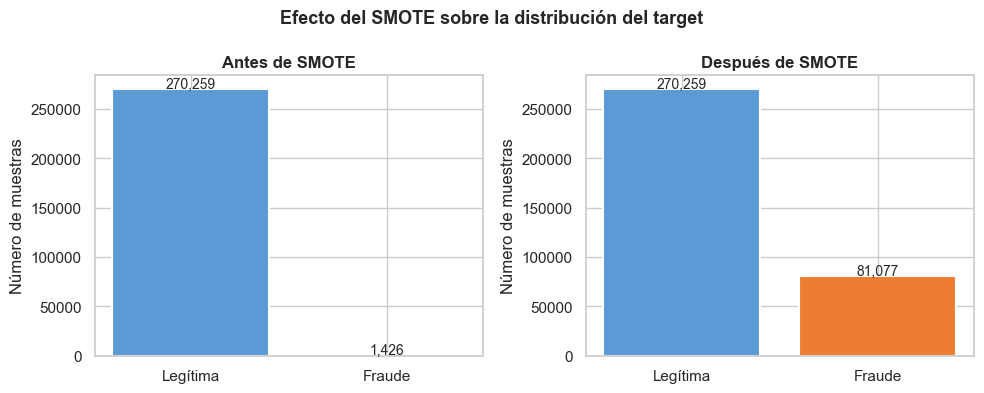

In [3]:
smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.3)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

vc_res = pd.Series(y_train_res).value_counts()
print('Distribución tras SMOTE:')
print(f'  Legítimas: {vc_res[0]:>7,}  ({vc_res[0]/len(y_train_res)*100:.2f}%)')
print(f'  Fraudes:   {vc_res[1]:>7,}  ({vc_res[1]/len(y_train_res)*100:.2f}%)')
print(f'  Total:     {len(y_train_res):>7,}')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y, titulo) in zip(axes, [(y_train, 'Antes de SMOTE'), (y_train_res, 'Después de SMOTE')]):
    vc_plot = pd.Series(y).value_counts()
    ax.bar(['Legítima', 'Fraude'], vc_plot.values,
           color=['#5B9BD5', '#ED7D31'], edgecolor='white', linewidth=1.5)
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('Número de muestras')
    for i, v in enumerate(vc_plot.values):
        ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=10)
plt.suptitle('Efecto del SMOTE sobre la distribución del target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Definición del modelo de Stacking

El modelo de Stacking combina las predicciones de múltiples modelos base mediante un metamodelo que aprende cómo pesarlas de forma óptima.

### Modelos base (nivel 0)

| Modelo | Parámetros clave | Justificación |
|--------|-----------------|---------------|
| Regresión Logística | `class_weight='balanced'` | Baseline lineal, rápido e interpretable |
| Árbol de Decisión | `max_depth=6`, `class_weight='balanced'` | Captura relaciones no lineales simples |
| K-Nearest Neighbors | `n_neighbors=7`, `weights='distance'` | Basado en similitud local |

### Metamodelo (nivel 1)
**Regresión Logística** — aprende a combinar las probabilidades de los modelos base de forma óptima, con validación cruzada interna de 5 folds.

In [4]:
# Ratio de desbalanceo para XGBoost (fraudes / legítimas tras SMOTE)
ratio_clases = int(vc_res[0] / vc_res[1])
print(f'scale_pos_weight para XGBoost: {ratio_clases}')

# ── Modelos base ────────────────────────────────────────────────────────────
modelos_base = [
    ('lr', LogisticRegression(
        max_iter=500,
        class_weight='balanced',
        solver='lbfgs',
        random_state=RANDOM_STATE
    )),
    ('dt', DecisionTreeClassifier(
        max_depth=6,
        criterion='entropy',
        class_weight='balanced',
        random_state=RANDOM_STATE
    )),
    ('knn', KNeighborsClassifier(
        n_neighbors=7,
        weights='distance',
        n_jobs=-1
    )),
]

# ── Metamodelo ───────────────────────────────────────────────────────────────
meta_modelo = LogisticRegression(max_iter=300, random_state=RANDOM_STATE)

# ── Stacking ─────────────────────────────────────────────────────────────────
stacking_model = StackingClassifier(
    estimators=modelos_base,
    final_estimator=meta_modelo,
    cv=5,          # Validación cruzada interna para generar las meta-features
    stack_method='predict_proba',
    n_jobs=-1
)

print(f'Modelo de Stacking definido con {len(modelos_base)} modelos base.')
print(f'Modelos base: {[nombre for nombre, _ in modelos_base]}')
print(f'Metamodelo:   LogisticRegression')

scale_pos_weight para XGBoost: 3
Modelo de Stacking definido con 3 modelos base.
Modelos base: ['lr', 'dt', 'knn']
Metamodelo:   LogisticRegression


## 5. Entrenamiento

In [5]:
import time

print('Entrenando modelo de Stacking...')
print(f'Muestras de entrenamiento (tras SMOTE): {len(X_train_res):,}')
print('(Este proceso puede tardar varios minutos)\n')

t0 = time.time()
stacking_model.fit(X_train_res, y_train_res)
t1 = time.time()

print(f'Entrenamiento completado en {(t1-t0)/60:.1f} minutos.')

Entrenando modelo de Stacking...
Muestras de entrenamiento (tras SMOTE): 351,336
(Este proceso puede tardar varios minutos)

Entrenamiento completado en 1.6 minutos.


## 6. Evaluación del modelo de Stacking

In [6]:
y_pred  = stacking_model.predict(X_test)
y_proba = stacking_model.predict_proba(X_test)[:, 1]

print('=' * 55)
print('   RESULTADOS — MODELO DE STACKING')
print('=' * 55)
print(classification_report(y_test, y_pred,
                             target_names=['Legítima (0)', 'Fraude (1)']))

# Métricas adicionales
roc_auc  = roc_auc_score(y_test, y_proba)
pr_auc   = average_precision_score(y_test, y_proba)
mcc      = matthews_corrcoef(y_test, y_pred)
f1       = f1_score(y_test, y_pred)

print(f'ROC-AUC : {roc_auc:.4f}')
print(f'PR-AUC  : {pr_auc:.4f}   ← métrica clave en datos desbalanceados')
print(f'MCC     : {mcc:.4f}   ← coeficiente de correlación de Matthews')
print(f'F1-Score: {f1:.4f}')

   RESULTADOS — MODELO DE STACKING
              precision    recall  f1-score   support

Legítima (0)       1.00      1.00      1.00     67566
  Fraude (1)       0.25      0.26      0.25       356

    accuracy                           0.99     67922
   macro avg       0.62      0.63      0.62     67922
weighted avg       0.99      0.99      0.99     67922

ROC-AUC : 0.8825
PR-AUC  : 0.2310   ← métrica clave en datos desbalanceados
MCC     : 0.2495   ← coeficiente de correlación de Matthews
F1-Score: 0.2534


## 7. Comparativa: modelos base individuales vs Stacking

Evaluamos cada modelo base de forma individual para demostrar que el Stacking mejora el rendimiento conjunto.

In [7]:
resultados = []

# Evaluación de cada modelo base (ya entrenados dentro del StackingClassifier)
for nombre, modelo in stacking_model.named_estimators_.items():
    y_pred_i = modelo.predict(X_test)
    y_prob_i = modelo.predict_proba(X_test)[:, 1]

    precision_c, recall_c, _ = precision_recall_curve(y_test, y_prob_i)

    resultados.append({
        'Modelo':    nombre.upper(),
        'Accuracy':  round(accuracy_score(y_test, y_pred_i), 4),
        'F1-Score':  round(f1_score(y_test, y_pred_i), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob_i), 4),
        'PR-AUC':    round(auc(recall_c, precision_c), 4),
        'MCC':       round(matthews_corrcoef(y_test, y_pred_i), 4),
    })

# Stacking final
precision_st, recall_st, _ = precision_recall_curve(y_test, y_proba)
resultados.append({
    'Modelo':    'STACKING (FINAL)',
    'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    'F1-Score':  round(f1_score(y_test, y_pred), 4),
    'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4),
    'PR-AUC':    round(auc(recall_st, precision_st), 4),
    'MCC':       round(matthews_corrcoef(y_test, y_pred), 4),
})

df_comparativa = pd.DataFrame(resultados).set_index('Modelo')

# Resaltar la fila del Stacking
def highlight_stacking(row):
    return ['background-color: #fff3cd; font-weight: bold' if row.name == 'STACKING (FINAL)'
            else '' for _ in row]

print('--- TABLA COMPARATIVA: MODELOS BASE VS STACKING ---')
display(df_comparativa.style
        .apply(highlight_stacking, axis=1)
        .format('{:.4f}')
        .background_gradient(cmap='Blues', subset=['ROC-AUC', 'PR-AUC'])
        .background_gradient(cmap='Greens', subset=['F1-Score', 'MCC']))

--- TABLA COMPARATIVA: MODELOS BASE VS STACKING ---


,Accuracy,F1-Score,ROC-AUC,PR-AUC,MCC
Modelo,,,,,
LR,0.7431,0.0264,0.7801,0.0708,0.0675
DT,0.9252,0.0672,0.8669,0.2964,0.1211
KNN,0.9756,0.1479,0.7385,0.1829,0.1829
STACKING (FINAL),0.9919,0.2534,0.8825,0.2306,0.2495


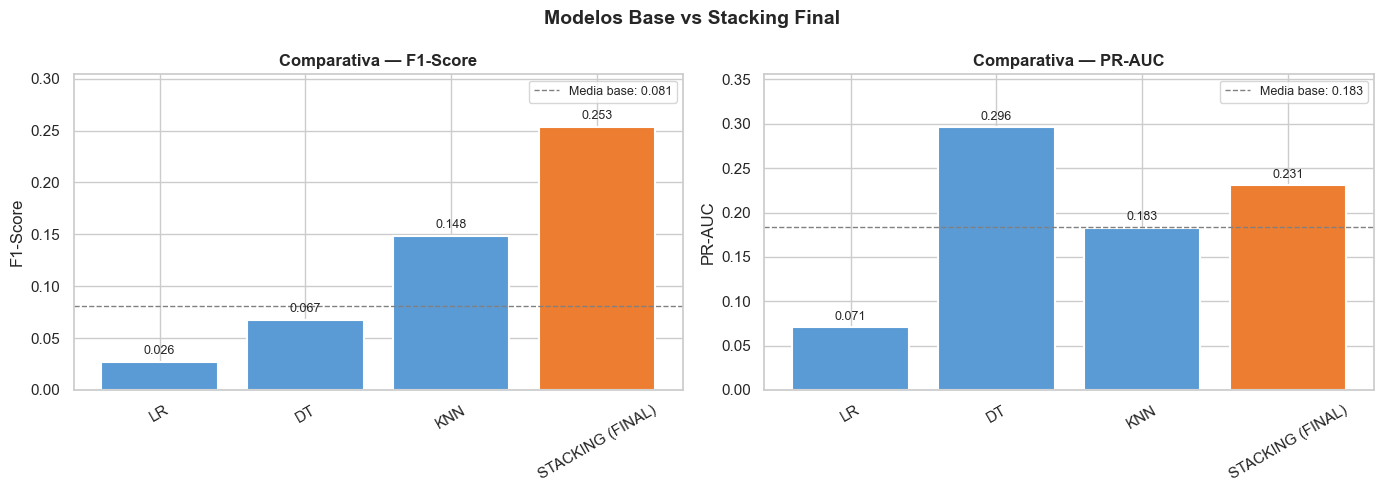

In [8]:
# Gráfico comparativo de métricas clave
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metricas_plot = ['F1-Score', 'PR-AUC']
colores = ['#5B9BD5' if idx != 'STACKING (FINAL)' else '#ED7D31'
           for idx in df_comparativa.index]

for ax, metrica in zip(axes, metricas_plot):
    bars = ax.bar(df_comparativa.index, df_comparativa[metrica],
                  color=colores, edgecolor='white', linewidth=1.5)
    ax.set_title(f'Comparativa — {metrica}', fontweight='bold', fontsize=12)
    ax.set_ylabel(metrica)
    ax.set_ylim(0, df_comparativa[metrica].max() * 1.2)
    ax.tick_params(axis='x', rotation=30)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=9)
    # Línea media de referencia
    media = df_comparativa[metrica].drop('STACKING (FINAL)').mean()
    ax.axhline(media, color='gray', linestyle='--', linewidth=1,
               label=f'Media base: {media:.3f}')
    ax.legend(fontsize=9)

plt.suptitle('Modelos Base vs Stacking Final', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Visualizaciones

### 8.1 Matriz de confusión

Verdaderos Negativos (TN):  67,281  — legítimas correctamente identificadas
Falsos Positivos   (FP):    285  — legítimas clasificadas como fraude (falsas alarmas)
Falsos Negativos   (FN):    263  — fraudes no detectados (más costosos)
Verdaderos Positivos (TP):  93  — fraudes correctamente detectados

Tasa de detección de fraude: 26.1%


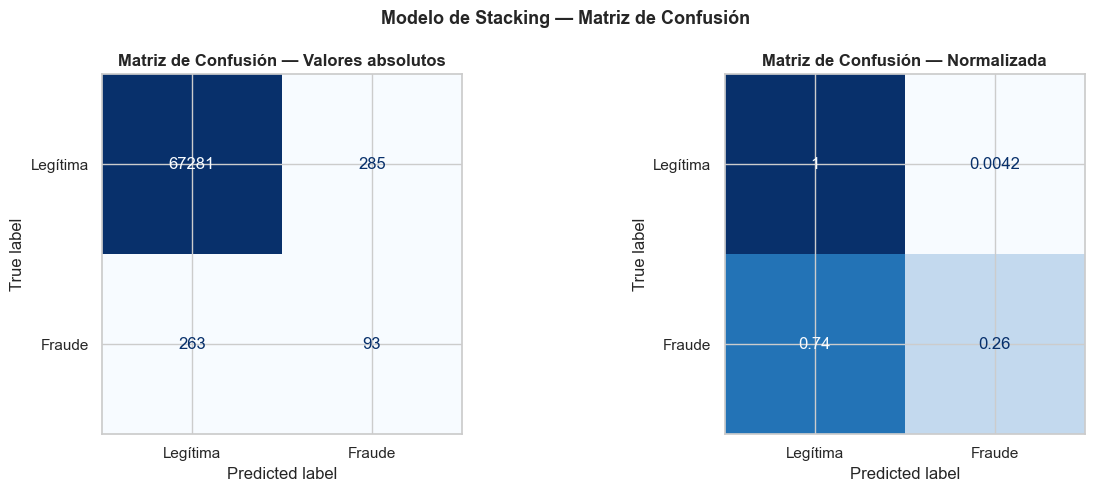

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz absoluta
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Legítima', 'Fraude'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión — Valores absolutos', fontweight='bold')

# Matriz normalizada
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                    display_labels=['Legítima', 'Fraude'])
disp_norm.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión — Normalizada', fontweight='bold')

# Anotaciones interpretativas
tn, fp, fn, tp = cm.ravel()
print(f'Verdaderos Negativos (TN):  {tn:,}  — legítimas correctamente identificadas')
print(f'Falsos Positivos   (FP):    {fp:,}  — legítimas clasificadas como fraude (falsas alarmas)')
print(f'Falsos Negativos   (FN):    {fn:,}  — fraudes no detectados (más costosos)')
print(f'Verdaderos Positivos (TP):  {tp:,}  — fraudes correctamente detectados')
print(f'\nTasa de detección de fraude: {tp/(tp+fn)*100:.1f}%')

plt.suptitle('Modelo de Stacking — Matriz de Confusión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 Curva ROC

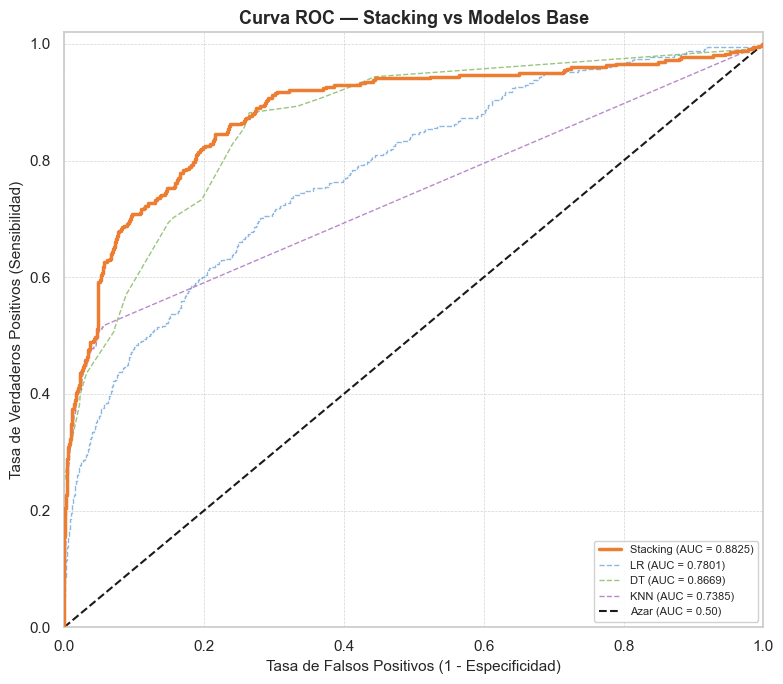

Curva ROC guardada en ../data/curva_roc.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 7))

# Curva del Stacking
fpr_st, tpr_st, _ = roc_curve(y_test, y_proba)
ax.plot(fpr_st, tpr_st, color='#ED7D31', lw=2.5,
        label=f'Stacking (AUC = {roc_auc:.4f})', zorder=5)

# Curvas de cada modelo base
colores_base = ['#5B9BD5','#70AD47','#9B59B6','#E74C3C','#1ABC9C','#F39C12','#2980B9','#BDC3C7']
for (nombre, modelo), color in zip(stacking_model.named_estimators_.items(), colores_base):
    y_prob_i = modelo.predict_proba(X_test)[:, 1]
    fpr_i, tpr_i, _ = roc_curve(y_test, y_prob_i)
    auc_i = roc_auc_score(y_test, y_prob_i)
    ax.plot(fpr_i, tpr_i, lw=1, linestyle='--', color=color, alpha=0.7,
            label=f'{nombre.upper()} (AUC = {auc_i:.4f})')

# Línea de azar
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Azar (AUC = 0.50)')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
ax.set_title('Curva ROC — Stacking vs Modelos Base', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
ax.grid(color='lightgray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('../data/curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Curva ROC guardada en ../data/curva_roc.png')

### 8.3 Curva Precision-Recall

En datasets desbalanceados, la curva PR es más informativa que la ROC, ya que se centra en el rendimiento sobre la clase minoritaria (fraude).

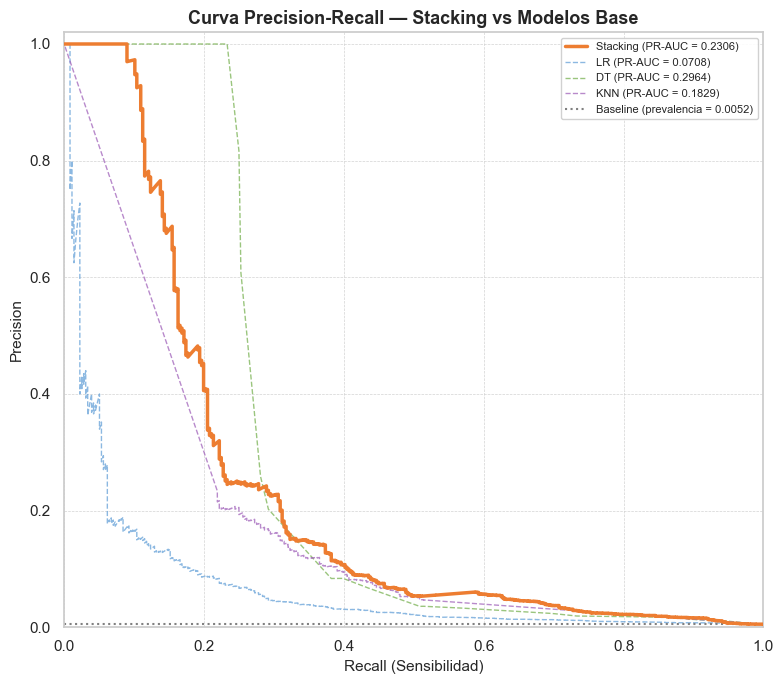

In [11]:
fig, ax = plt.subplots(figsize=(8, 7))

# Stacking
prec_st, rec_st, _ = precision_recall_curve(y_test, y_proba)
pr_auc_st = auc(rec_st, prec_st)
ax.plot(rec_st, prec_st, color='#ED7D31', lw=2.5,
        label=f'Stacking (PR-AUC = {pr_auc_st:.4f})', zorder=5)

# Modelos base
for (nombre, modelo), color in zip(stacking_model.named_estimators_.items(), colores_base):
    y_prob_i = modelo.predict_proba(X_test)[:, 1]
    prec_i, rec_i, _ = precision_recall_curve(y_test, y_prob_i)
    pr_i = auc(rec_i, prec_i)
    ax.plot(rec_i, prec_i, lw=1, linestyle='--', color=color, alpha=0.7,
            label=f'{nombre.upper()} (PR-AUC = {pr_i:.4f})')

# Baseline (prevalencia de fraude)
baseline = y_test.mean()
ax.axhline(baseline, color='gray', linestyle=':', lw=1.5,
           label=f'Baseline (prevalencia = {baseline:.4f})')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Recall (Sensibilidad)', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Curva Precision-Recall — Stacking vs Modelos Base', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
ax.grid(color='lightgray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('../data/curva_pr.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.4 Importancia de variables

Extraemos la importancia de variables de los modelos base que la soportan (Random Forest, Gradient Boosting, XGBoost y Árbol de Decisión).

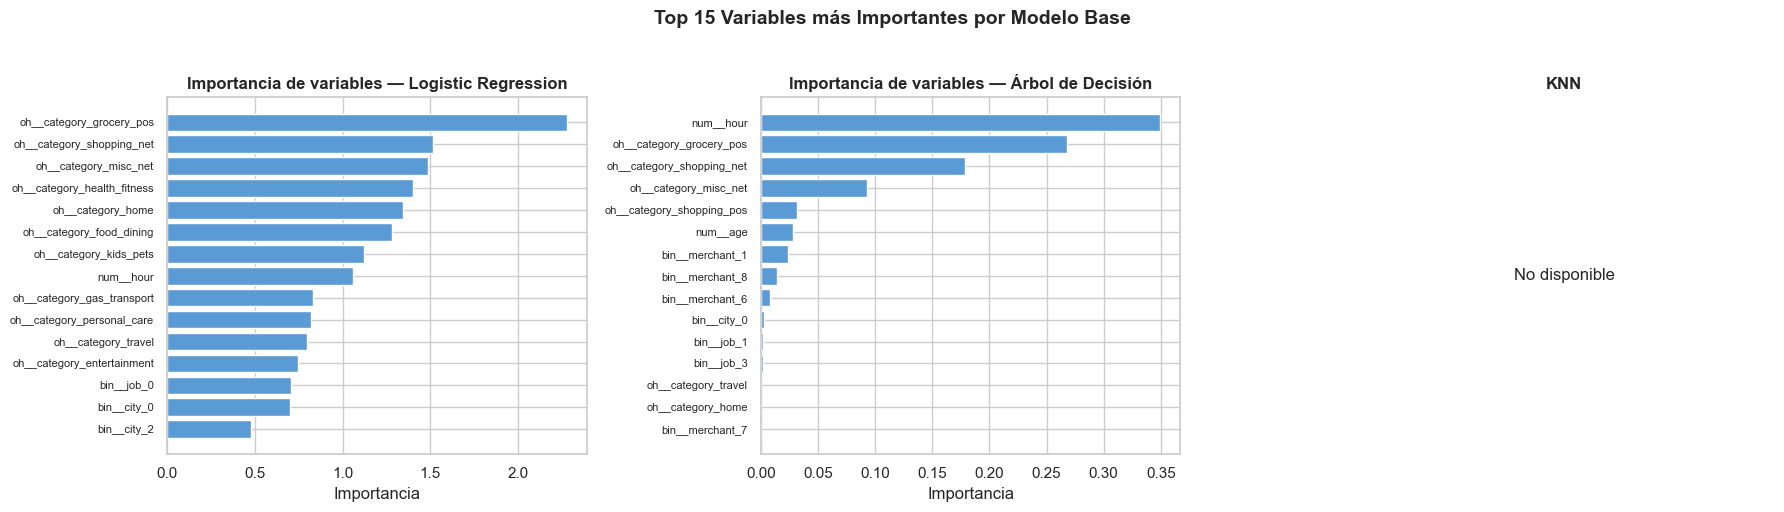

In [13]:
modelos_importancia = {
    'Logistic Regression': stacking_model.named_estimators_['lr'],
    'Árbol de Decisión':   stacking_model.named_estimators_['dt'],
    'KNN':                 stacking_model.named_estimators_['knn'],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for ax, (nombre, modelo) in zip(axes, modelos_importancia.items()):
    
    # Caso 1: modelos con feature_importances_
    if hasattr(modelo, "feature_importances_"):
        importancias = modelo.feature_importances_
    
    # Caso 2: Logistic Regression → usar coeficientes
    elif hasattr(modelo, "coef_"):
        importancias = np.abs(modelo.coef_[0])
    
    # Caso 3: modelos sin importancia (KNN)
    else:
        ax.text(0.5, 0.5, 'No disponible', 
                horizontalalignment='center', 
                verticalalignment='center',
                fontsize=12)
        ax.set_title(f'{nombre}', fontweight='bold')
        ax.axis('off')
        continue

    feat_imp = pd.Series(importancias, index=feature_cols)\
                  .sort_values(ascending=False)\
                  .head(15)

    ax.barh(feat_imp.index[::-1], feat_imp.values[::-1],
            color='#5B9BD5', edgecolor='white')

    ax.set_title(f'Importancia de variables — {nombre}', fontweight='bold')
    ax.set_xlabel('Importancia')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Top 15 Variables más Importantes por Modelo Base',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

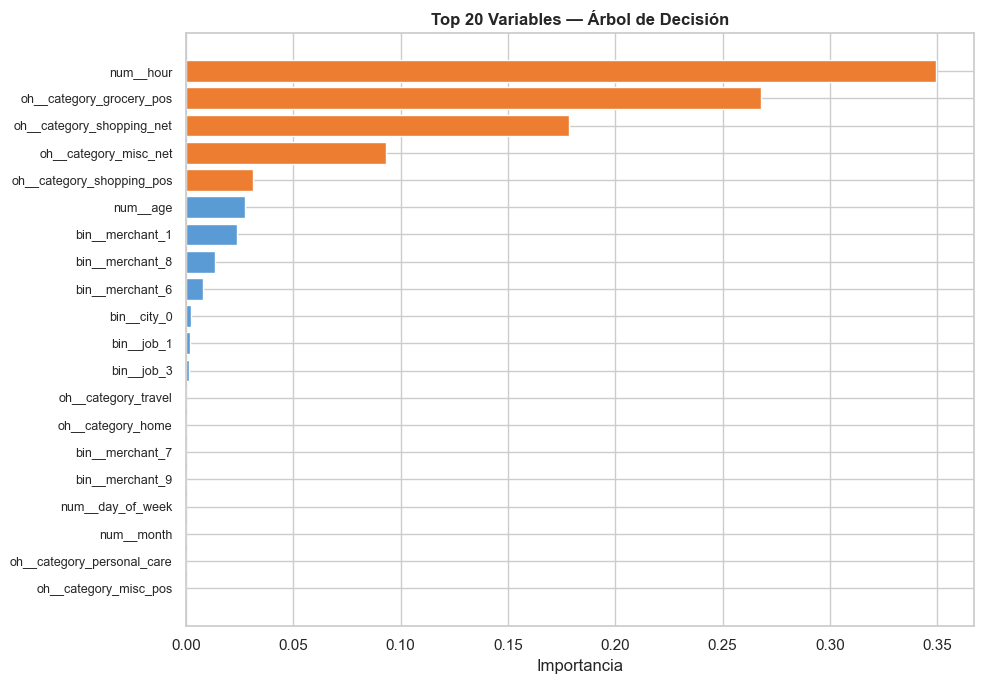

In [15]:
imp_dt = stacking_model.named_estimators_['dt'].feature_importances_

feat_imp = pd.Series(imp_dt, index=feature_cols)\
                .sort_values(ascending=False)\
                .head(20)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(feat_imp.index[::-1], feat_imp.values[::-1],
        color=['#ED7D31' if i < 5 else '#5B9BD5'
               for i in range(len(feat_imp)-1, -1, -1)],
        edgecolor='white')

ax.set_title('Top 20 Variables — Árbol de Decisión',
             fontweight='bold', fontsize=12)

ax.set_xlabel('Importancia')
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

### 8.5 Análisis del umbral de decisión

En detección de fraude, el umbral de clasificación por defecto (0.5) no siempre es óptimo. Analizamos cómo varía la Precision y el Recall al ajustarlo.

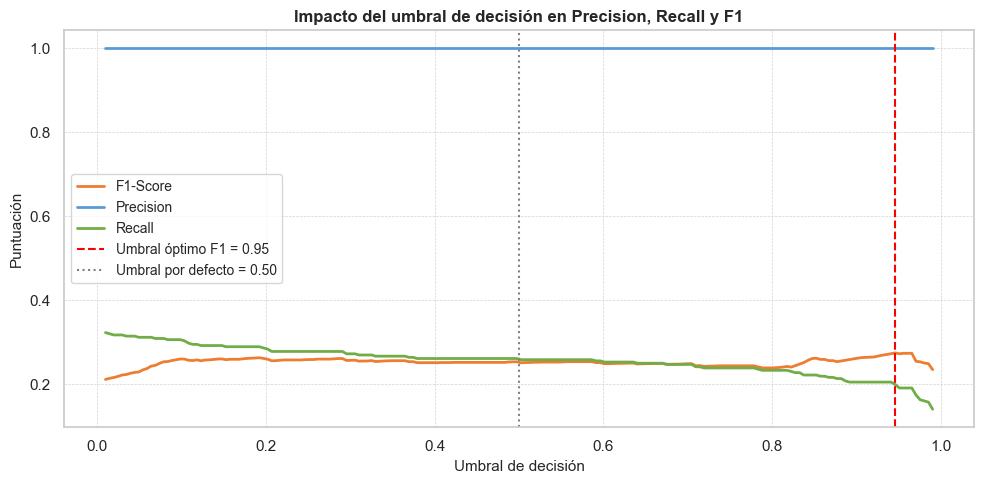

Umbral óptimo para F1-Score: 0.95
F1-Score con umbral óptimo:  0.2747
F1-Score con umbral 0.50:    0.2534


In [16]:
thresholds_range = np.linspace(0.01, 0.99, 200)
f1_scores, precisions, recalls = [], [], []

for thr in thresholds_range:
    y_pred_thr = (y_proba >= thr).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_thr, zero_division=0))
    precisions.append(pd.Series(y_pred_thr[y_pred_thr == 1]).shape[0] /
                      max(y_pred_thr.sum(), 1))
    from sklearn.metrics import recall_score
    recalls.append(recall_score(y_test, y_pred_thr, zero_division=0))

umbral_optimo = thresholds_range[np.argmax(f1_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_range, f1_scores,   color='#ED7D31', lw=2, label='F1-Score')
ax.plot(thresholds_range, precisions,  color='#5B9BD5', lw=2, label='Precision')
ax.plot(thresholds_range, recalls,     color='#70AD47', lw=2, label='Recall')
ax.axvline(umbral_optimo, color='red', linestyle='--', lw=1.5,
           label=f'Umbral óptimo F1 = {umbral_optimo:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', lw=1.5, label='Umbral por defecto = 0.50')
ax.set_xlabel('Umbral de decisión', fontsize=11)
ax.set_ylabel('Puntuación', fontsize=11)
ax.set_title('Impacto del umbral de decisión en Precision, Recall y F1',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(color='lightgray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

print(f'Umbral óptimo para F1-Score: {umbral_optimo:.2f}')
y_pred_opt = (y_proba >= umbral_optimo).astype(int)
print(f'F1-Score con umbral óptimo:  {f1_score(y_test, y_pred_opt):.4f}')
print(f'F1-Score con umbral 0.50:    {f1_score(y_test, y_pred):.4f}')

## 9. Resumen final

In [17]:
print('=' * 60)
print('   RESUMEN FINAL — MODELO DE STACKING')
print('=' * 60)
print(f'\n  Modelos base ({len(modelos_base)}):')
for nombre, _ in modelos_base:
    print(f'    · {nombre.upper()}')
print(f'\n  Metamodelo: LogisticRegression')
print(f'  Validación cruzada interna: 5-fold')
print(f'  Tratamiento desbalanceo: SMOTE (ratio 1:3)')
print(f'\n  Métricas sobre test ({len(y_test):,} muestras):')
print(f'    ROC-AUC:  {roc_auc_score(y_test, y_proba):.4f}')
print(f'    PR-AUC:   {average_precision_score(y_test, y_proba):.4f}')
print(f'    F1-Score: {f1_score(y_test, y_pred):.4f}')
print(f'    MCC:      {matthews_corrcoef(y_test, y_pred):.4f}')
print(f'\n  Umbral óptimo (F1): {umbral_optimo:.2f}')
print(f'  F1 con umbral óptimo: {f1_score(y_test, y_pred_opt):.4f}')
print('=' * 60)

   RESUMEN FINAL — MODELO DE STACKING

  Modelos base (3):
    · LR
    · DT
    · KNN

  Metamodelo: LogisticRegression
  Validación cruzada interna: 5-fold
  Tratamiento desbalanceo: SMOTE (ratio 1:3)

  Métricas sobre test (67,922 muestras):
    ROC-AUC:  0.8825
    PR-AUC:   0.2310
    F1-Score: 0.2534
    MCC:      0.2495

  Umbral óptimo (F1): 0.95
  F1 con umbral óptimo: 0.2747
